# Project 2: Exploratory Data Analysis (EDA)

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Cleaned_Dataset.xlsx")
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Dataset Overview

In [2]:
print("Shape:", df.shape)
df.info()


Shape: (1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


## Missing Values Check

In [3]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

## Statistical Summary

In [4]:
numerical_cols = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
df[numerical_cols].describe().round(2)


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


## Median Values

In [5]:
df[numerical_cols].median()

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

## Count Values

In [6]:
df[numerical_cols].count()

Quantity       1200
UnitPrice      1200
ItemsInCart    1200
TotalPrice     1200
dtype: int64

## Business KPIs

In [7]:
print("Total Revenue:", df['TotalPrice'].sum())
print("Average Order Value:", round(df['TotalPrice'].mean(),2))
print("Total Orders:", df['OrderID'].nunique())
print("Total Customers:", df['CustomerID'].nunique())


Total Revenue: 1264761.96
Average Order Value: 1053.97
Total Orders: 1200
Total Customers: 1189


## Distribution Analysis

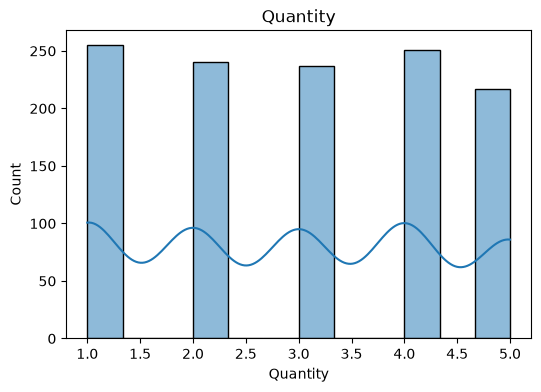

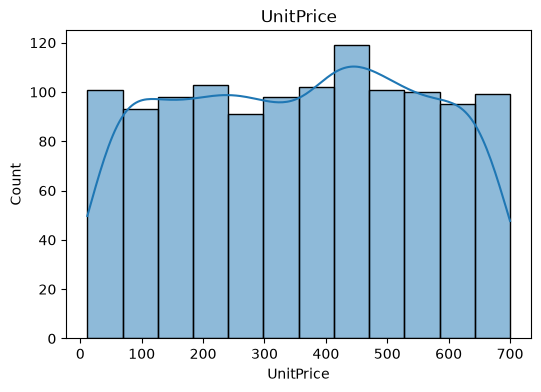

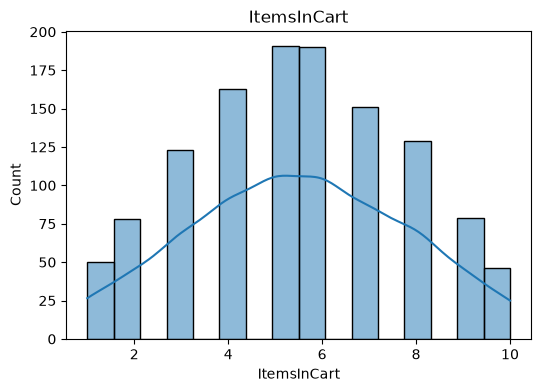

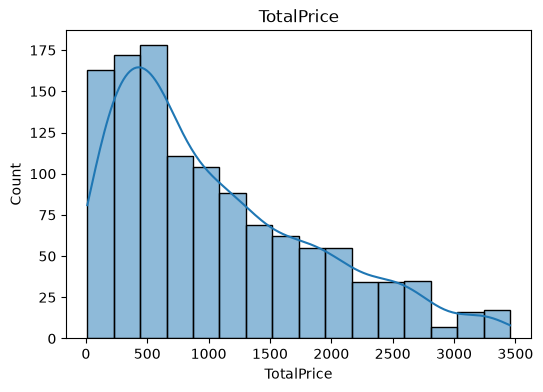

In [8]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


### Findings
Add observations after reviewing the distributions.

## Product Analysis

In [9]:
top_products = df.groupby('Product')['Quantity'].sum()
top_products.sort_values(ascending=False).head(10)


Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

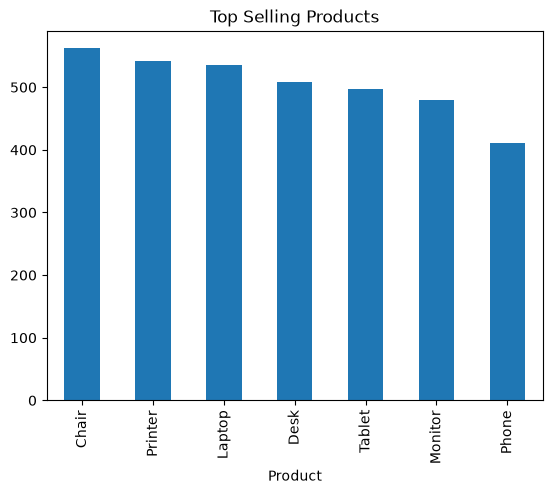

In [10]:
top_products.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Selling Products')
plt.show()


### Findings
Identify the products with highest and lowest sales.

## Revenue by Product

In [11]:
revenue_product = df.groupby('Product')['TotalPrice'].sum()
revenue_product.sort_values(ascending=False).head(10)


Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

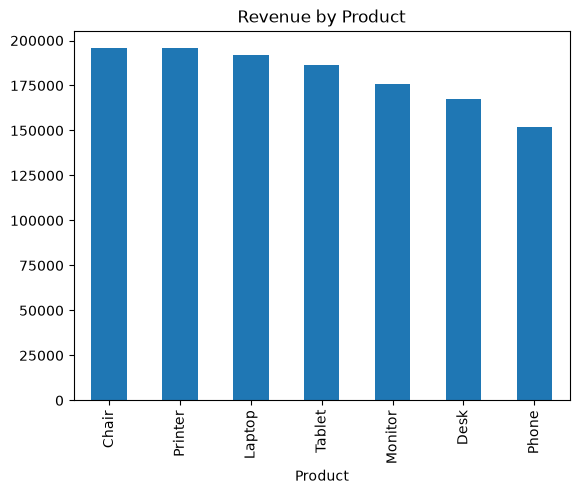

In [12]:
revenue_product.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Revenue by Product')
plt.show()


## Payment Method Analysis

In [13]:
df['PaymentMethod'].value_counts()


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

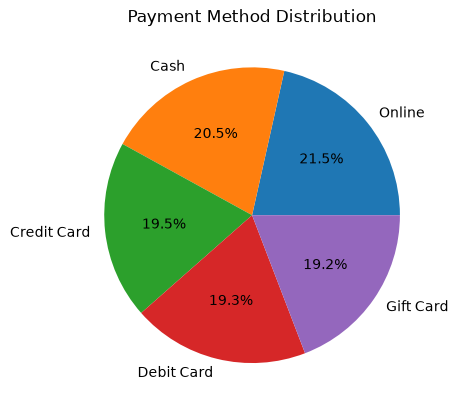

In [14]:
df['PaymentMethod'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Payment Method Distribution')
plt.show()


## Order Status Analysis

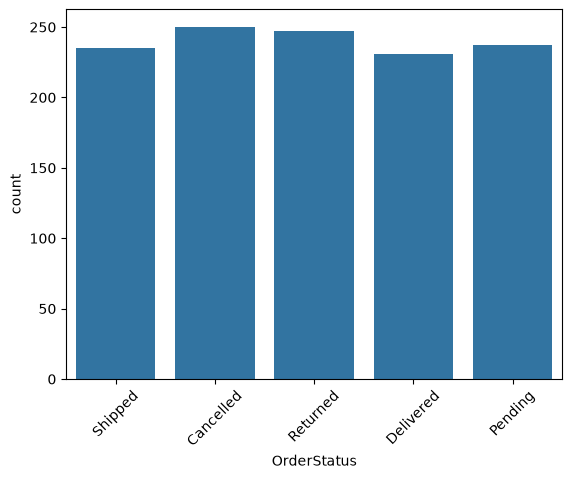

In [15]:
df['OrderStatus'].value_counts()
sns.countplot(data=df, x='OrderStatus')
plt.xticks(rotation=45)
plt.show()


## Referral Source Analysis

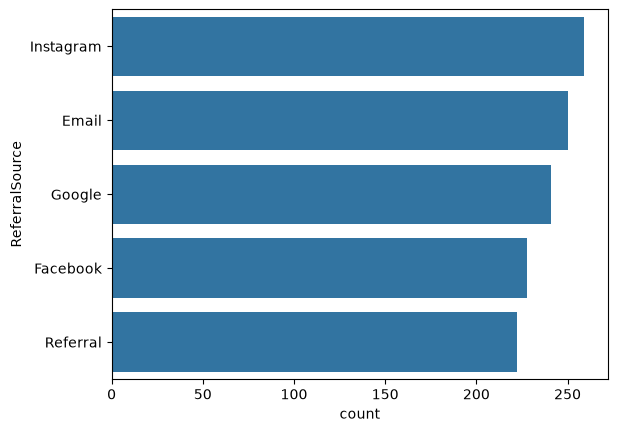

In [16]:
df['ReferralSource'].value_counts()
sns.countplot(data=df, y='ReferralSource', order=df['ReferralSource'].value_counts().index)
plt.show()


## Coupon Analysis

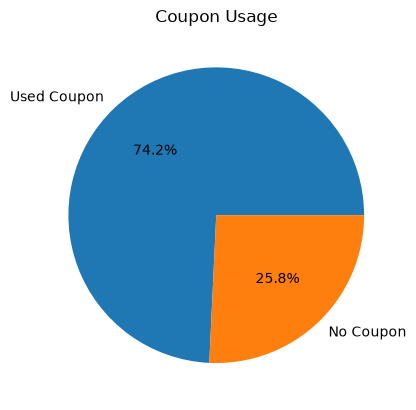

Used Coupon: 891
No Coupon: 309


In [17]:
used_coupon = (df['CouponCode'] != 'No Coupon').sum()
no_coupon = (df['CouponCode'] == 'No Coupon').sum()

plt.pie([used_coupon, no_coupon],
        labels=['Used Coupon','No Coupon'],
        autopct='%1.1f%%')
plt.title('Coupon Usage')
plt.show()

print("Used Coupon:", used_coupon)
print("No Coupon:", no_coupon)


## Monthly Sales Trend

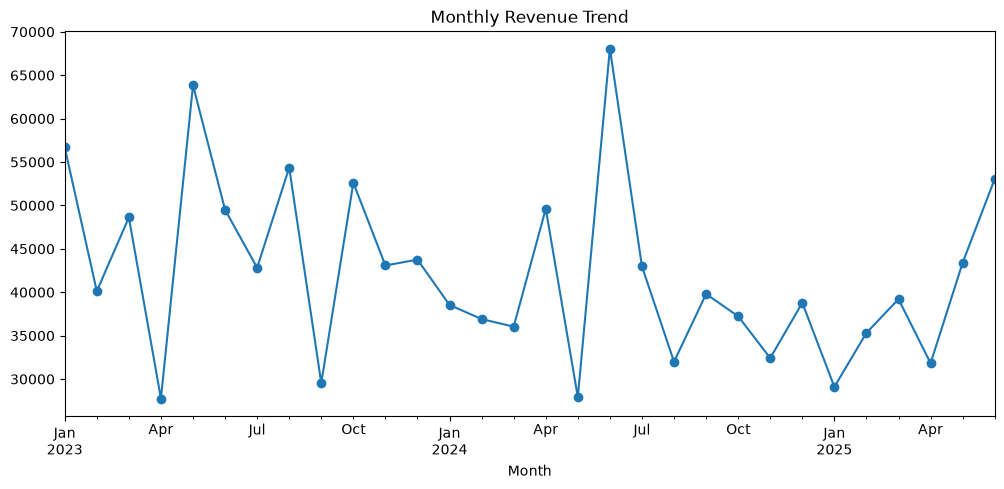

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(figsize=(12,5), marker='o')
plt.title('Monthly Revenue Trend')
plt.show()


## Outlier Detection

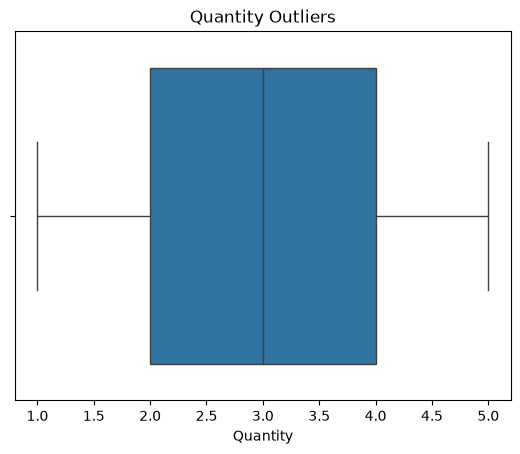

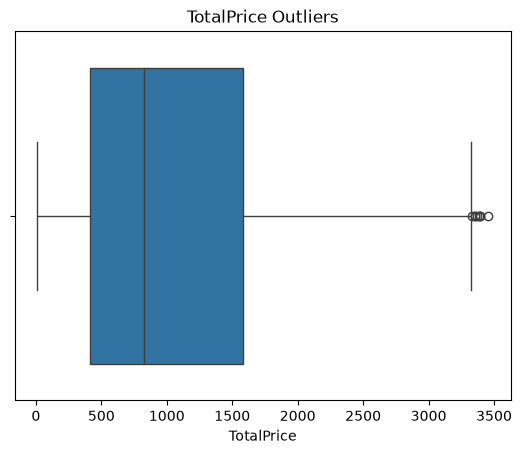

In [19]:
sns.boxplot(x=df['Quantity'])
plt.title('Quantity Outliers')
plt.show()

sns.boxplot(x=df['TotalPrice'])
plt.title('TotalPrice Outliers')
plt.show()


## Correlation Analysis

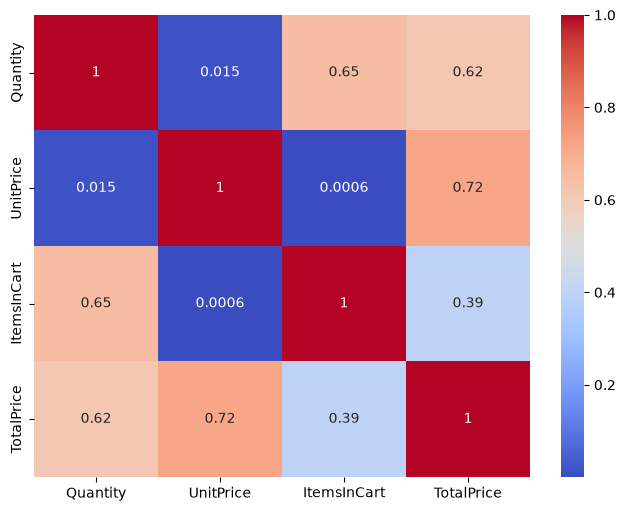

In [20]:
numeric_df = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


# Final Insights

1. Analyze KPI results and summarize revenue performance.
2. Identify the highest-selling and highest-revenue products.
3. Highlight preferred payment methods.
4. Discuss coupon adoption rate.
5. Explain referral source performance.
6. Mention monthly sales trends.
7. Discuss detected outliers.
8. Summarize key correlations.
